In [ ]:
import os
import kagglehub
import pandas as pd
from rich.table import Table
from rich.console import Console
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

/home/morteza/hobby/univercity/ISI/Proj/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROXY = "http://localhost:2080"
NROWS = 500000

In [5]:


def get_dataset_with_proxy() -> tuple[str, str]:

    previous_http_proxy = os.environ.get('HTTP_PROXY')
    previous_https_proxy = os.environ.get('HTTPS_PROXY')

    os.environ['HTTP_PROXY'] = PROXY
    os.environ['HTTPS_PROXY'] = PROXY
    path = kagglehub.dataset_download("wordsforthewise/lending-club")

    if previous_http_proxy is not None:
        os.environ['HTTP_PROXY'] = previous_http_proxy
    if previous_https_proxy is not None:
        os.environ['HTTPS_PROXY'] = previous_https_proxy

    return path

path = get_dataset_with_proxy()
print("Path to dataset files:", path)

Path to dataset files: /home/morteza/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


In [6]:
accepted_df = pd.read_csv(os.path.join(path, 'accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv'), nrows=NROWS)
accepted_df["is_accepted"] = True

rejected_df = pd.read_csv(os.path.join(path, 'rejected_2007_to_2018Q4.csv/rejected_2007_to_2018Q4.csv'), nrows=NROWS)
rejected_df["is_accepted"] = False

df = pd.concat([accepted_df, rejected_df], ignore_index=True)
df.head()

/tmp/ipykernel_497476/4272063827.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: verification_status_joint, 3: sec_app_earliest_cr_line) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted_df = pd.read_csv(os.path.join(path, 'accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv'), nrows=NROWS)
/tmp/ipykernel_497476/4272063827.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  accepted_df["is_accepted"] = True


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,is_accepted,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Columns: 161 entries, id to Policy Code
dtypes: bool(1), float64(116), object(1), str(43)
memory usage: 1.2+ GB


In [8]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term,Amount Requested,Risk_Score,Policy Code
count,0.0,499998.000000,499998.000000,499998.000000,499998.000000,499998.000000,4.999980e+05,499782.000000,499998.000000,499998.000000,...,2753.000000,2250.000000,2753.000000,2753.000000,11749.000000,11749.000000,11749.000000,5.000000e+05,479294.000000,500000.0
mean,NaN,15388.960556,15388.960556,15383.220733,12.574207,446.388830,7.718632e+04,19.245352,0.328035,695.932524,...,14.180894,369.616440,9689.468649,185.516738,4889.392642,47.296572,12.871564,1.223684e+04,584.546906,0.0
std,NaN,8852.271158,8852.271158,8849.356048,4.438228,252.569027,7.534664e+04,12.055632,0.900866,31.800548,...,9.627358,311.237435,6546.966657,181.992956,3536.380711,6.328199,7.796861,1.013681e+04,187.871457,0.0
min,NaN,1000.000000,1000.000000,900.000000,5.310000,14.010000,0.000000e+00,0.000000,0.000000,660.000000,...,0.000000,1.920000,55.730000,0.020000,107.000000,0.450000,0.000000,5.000000e+02,0.000000,0.0
25%,NaN,8500.000000,8500.000000,8500.000000,9.170000,262.750000,4.600000e+04,12.390000,0.000000,670.000000,...,7.000000,128.392500,4348.310000,43.470000,2148.000000,45.000000,6.000000,4.500000e+03,557.000000,0.0
50%,NaN,14000.000000,14000.000000,14000.000000,12.290000,385.910000,6.500000e+04,18.470000,0.000000,690.000000,...,15.000000,291.390000,8500.230000,134.190000,4179.000000,45.000000,12.000000,1.000000e+04,643.000000,0.0
75%,NaN,20000.000000,20000.000000,20000.000000,15.590000,589.220000,9.200000e+04,25.310000,0.000000,710.000000,...,23.000000,516.480000,13750.790000,277.570000,6759.790000,50.000000,18.000000,2.000000e+04,688.000000,0.0
max,NaN,40000.000000,40000.000000,40000.000000,30.990000,1607.800000,9.500000e+06,999.000000,39.000000,845.000000,...,30.000000,2535.660000,38079.560000,1247.480000,30000.000000,166.670000,112.000000,1.400000e+06,849.000000,0.0


In [9]:
table = Table()
for col in ("name", "type", "unique count"):
    table.add_column(col)

for col in df.columns:
    col_data = df[col]
    table.add_row(col, str(col_data.dtype), str(len(col_data.unique())))

Console().log(table)

[22:48:25] ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┓                  ]8;id=588909;file:///tmp/ipykernel_497476/2983849493.py\2983849493.py]8;;\:]8;id=61564;file:///tmp/ipykernel_497476/2983849493.py#9\9]8;;\
           ┃ name                                       ┃ type    ┃ unique count ┃                                 
           ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━┩                                 
           │ id                                         │ object  │ 500001       │                                 
           │ member_id                                  │ float64 │ 1            │                                 
           │ loan_amnt                                  │ float64 │ 1494         │                                 
           │ funded_amnt                                │ float64 │ 1494         │                                 
           │ funded_amnt_inv                            │ float64 │ 1512         │                                 
           │ term                                       │ str     │ 3            │                                 
           │ int_rate                                   │ float64 │ 169          │                                 
           │ installment                                │ float64 │ 46678        │                                 
           │ grade                                      │ str     │ 8            │                                 
           │ sub_grade                                  │ str     │ 36           │                                 
           │ emp_title                                  │ str     │ 136375       │                                 
           │ emp_length                                 │ str     │ 12           │                                 
           │ home_ownership                             │ str     │ 5            │                                 
           │ annual_inc                                 │ float64 │ 31259        │                                 
           │ verification_status                        │ str     │ 4            │                                 
           │ issue_d                                    │ str     │ 16           │                                 
           │ loan_status                                │ str     │ 8            │                                 
           │ pymnt_plan                                 │ str     │ 3            │                                 
           │ url                                        │ str     │ 499999       │                                 
           │ desc                                       │ str     │ 35           │                                 
           │ purpose                                    │ str     │ 15           │                                 
           │ title                                      │ str     │ 28           │                                 
           │ zip_code                                   │ str     │ 917          │                                 
           │ addr_state                                 │ str     │ 51           │                                 
           │ dti                                        │ float64 │ 5886         │                                 
           │ delinq_2yrs                                │ float64 │ 27           │                                 
           │ earliest_cr_line                           │ str     │ 699          │                                 
           │ fico_range_low                             │ float64 │ 39           │                                 
           │ fico_range_high                            │ float64 │ 39           │                                 
           │ inq_last_6mths                             │ float64 │ 8            │                                 
           │ mths_since_last_delinq      

In [10]:
num_cols = list(filter(lambda x: df[x].dtype == np.float64, df.columns))
corr = df[num_cols].corr()

Text(0.5, 1.0, ' correlation values(excluded 1) logarithm of their abs value histogram ')

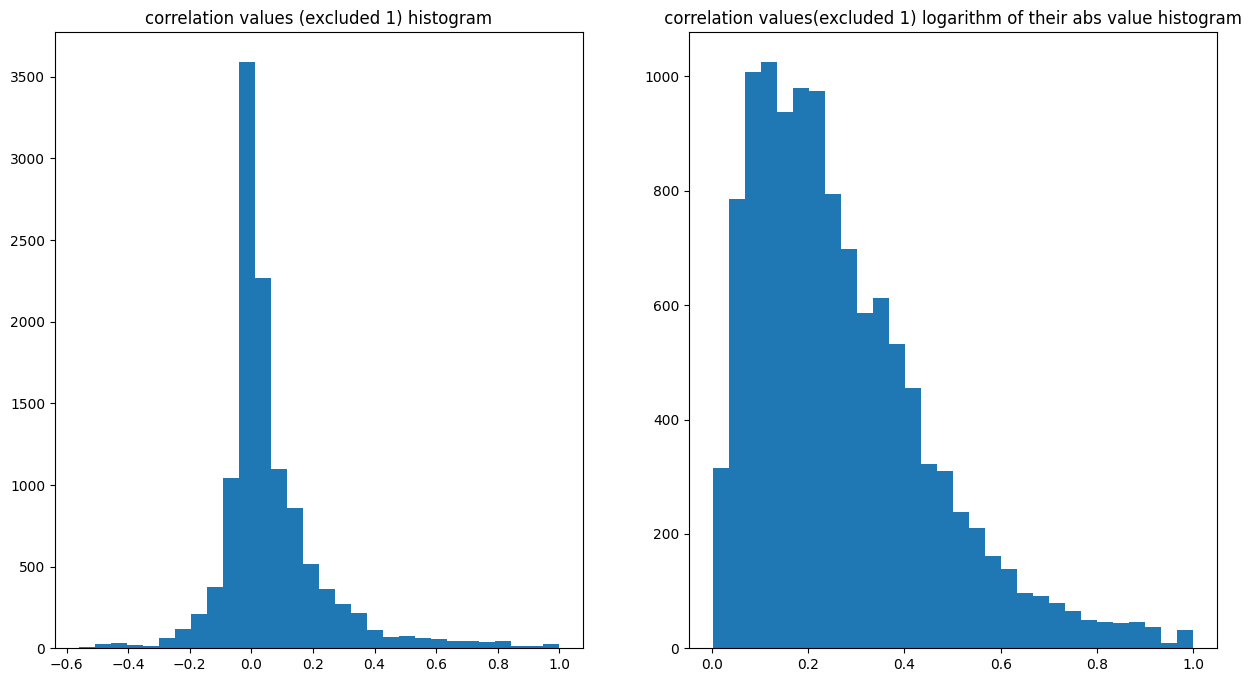

In [11]:
corr_arr = corr.to_numpy().flatten()
corr_arr = corr_arr[~np.isnan(corr_arr)]
corr_arr = corr_arr[corr_arr != 1]

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.hist(corr_arr, bins=30)
plt.title("correlation values (excluded 1) histogram")

plt.subplot(1, 2, 2)
plt.hist(np.sqrt(np.abs(corr_arr)), bins=30)
plt.title(" correlation values(excluded 1) logarithm of their abs value histogram ")

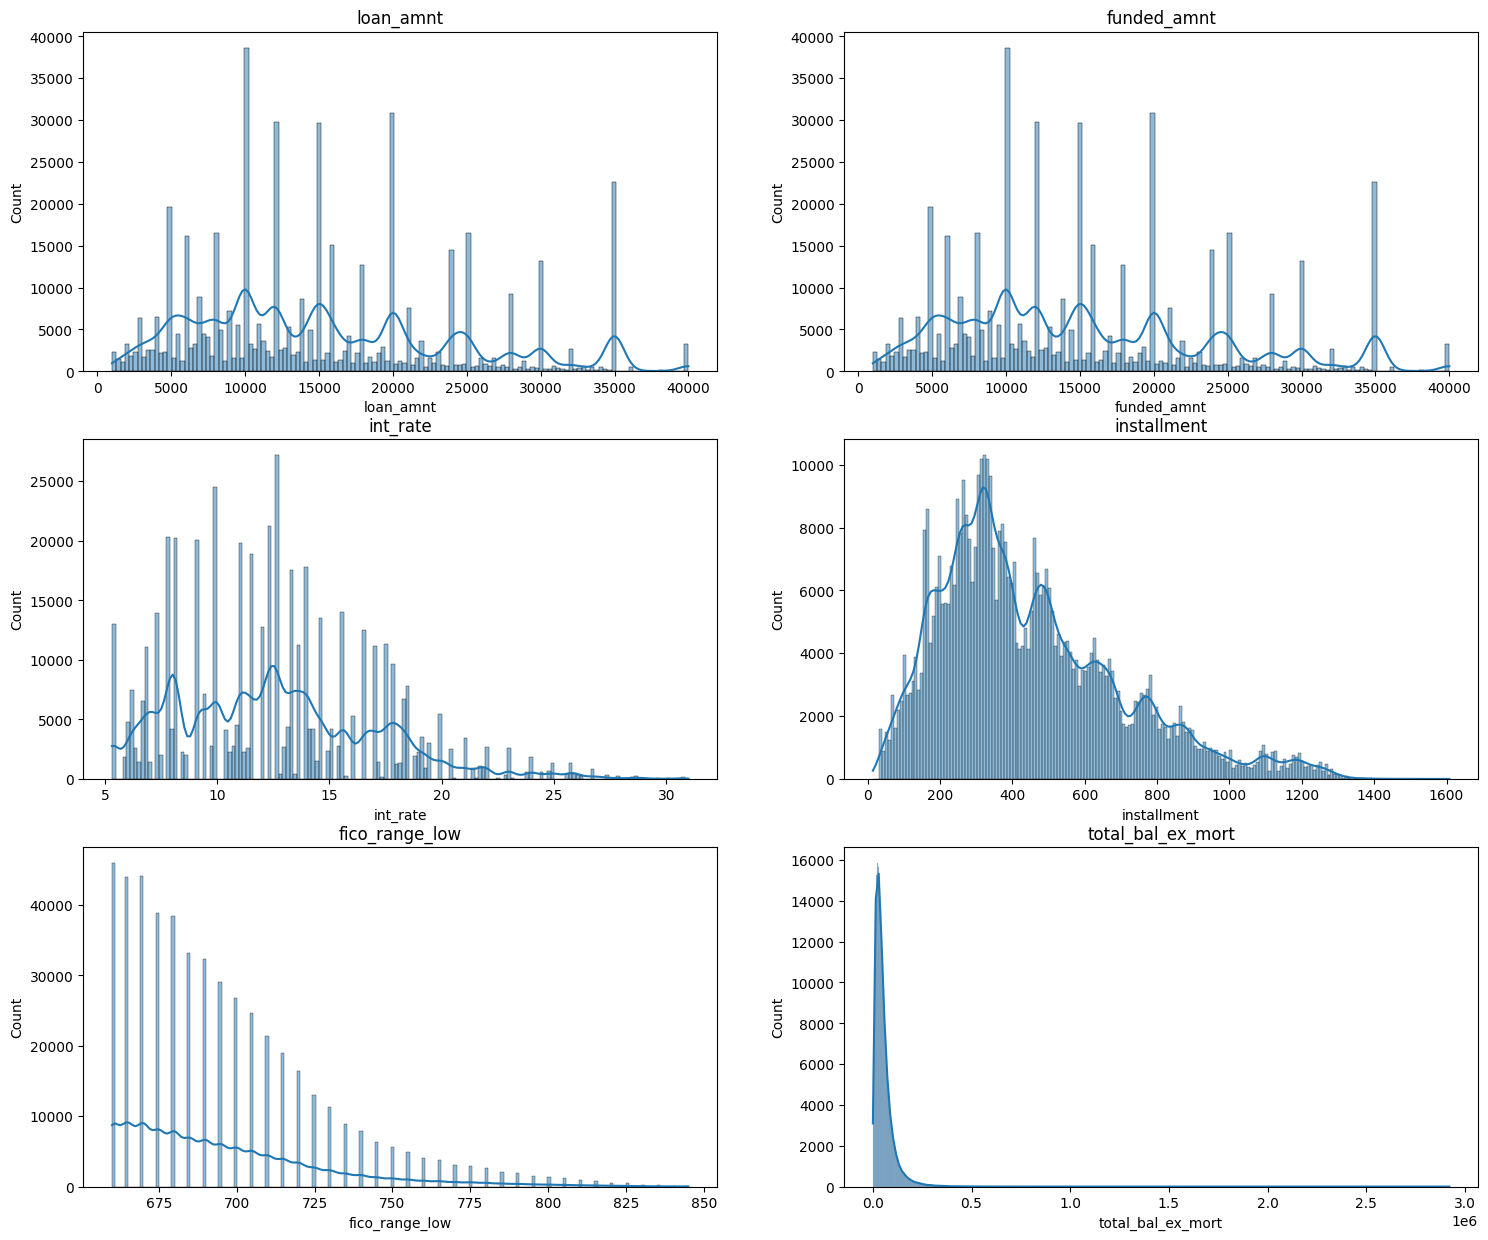

In [12]:

cols = (
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "fico_range_low",
    "total_bal_ex_mort"
)
plt.figure(figsize=(18, 15))
for i in range(3):
    for j in range(2):
        ind = i * 2 + j 
        col = cols[ind]
        plt.subplot(3, 2, ind + 1)
        sns.histplot(df[col], kde=True)
        plt.title(col)


In [14]:
df["verification_status"].value_counts()

verification_status
Source Verified    215223
Not Verified       143182
Verified           141593
Name: count, dtype: int64

In [19]:
df["disbursement_method"].value_counts()

disbursement_method
Cash         494250
DirectPay      5748
Name: count, dtype: int64